In [1]:
from assets import loadMelodic, select_files, corpora_parser, match_lengths, csv_export, csv_import
from music21 import *
from IPython.display import display
import pandas as pd
from nltk import FreqDist
from nltk.lm import Laplace, Vocabulary, MLE
from sklearn.model_selection import train_test_split
from nltk.util import pad_sequence
import statistics
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import nltk.classify.util
from nltk.classify import NaiveBayesClassifier
from plotters import plt_individuals, plt_individuals_colored, plt_folded, plt_by_classes
from decouple import config, AutoConfig
import os

#### Aquí se establece N

In [124]:
n = 3
mode = 'Ii'
voice_selec = 1
stack = False
diatonic = False
base40=True

In [3]:
## Atención: ejecutar este código

config = AutoConfig(' ')
inp = input(f"La carpeta contenedora de la música es {config('MUSIC_FOLDER')}. Introduzca un nombre distinto o N, para conservar el nombre: ")

if inp.upper() != 'N':
    with open('.env', 'r') as f:
        lines = f.readlines()

    with open('.env', 'w') as f:
        for line in lines:
            if line.startswith('MUSIC_FOLDER='):
                f.write(f'MUSIC_FOLDER={inp}\n')
            else:
                f.write(line)
    os.environ['MUSIC_FOLDER'] = inp
else:
    os.environ['MUSIC_FOLDER'] = config('MUSIC_FOLDER')

La carpeta contenedora de la música es Music_files. Introduzca un nombre distinto o N, para conservar el nombre:  N


#### Selección de archivos para cada dataset (compositor 1, compositor 2 y anónimos)

In [4]:
## 4 voces
morales_fnames_and_others_4 = select_files(split_by_voices=True)
otros_fnames_and_others_4 = select_files(split_by_voices=True, multiple_folder_selection=True)
test_fnames_and_others_4 = select_files(split_by_voices=True)

Introduzca el nombre del directorio de obras a cargar:  Morales
El conjunto contiene obras clasificadas en 6 agrupaciones diferentes con [2, 3, 4, 5, 6, 7] voces. ¿Qué subset desea importar?  4


Los datasets disponibles son:

['Anon', 'Claudin', 'Consilium', 'Courtois', 'Daser', 'Escobedo', 'Festa', 'Gombert', 'Guerrero', 'Ivo', 'J. Gero', 'Jacotin', 'Jaquet of Mantua', 'Maistre Jhan', 'Palestrina', 'Peñalosa', 'Phinot', 'Ruffo', 'Verdelot', 'Willaert']


Introduzca los directorios de interés, escriba "OK" para terminar, simplemente "All" o "All-[carpeta a excluir]"":  All-Anon
El conjunto contiene obras clasificadas en 7 agrupaciones diferentes con [3, 4, 5, 6, 7, 8, 9] voces. ¿Qué subset desea importar?  4
Introduzca el nombre del directorio de obras a cargar:  Anon
El conjunto contiene obras clasificadas en 1 agrupaciones diferentes con [4] voces. ¿Qué subset desea importar?  4


#### Extraer features de compositor 1: Morales

In [9]:
## Aclaración de uso:
#Si queremos importar todos los archivos, independientemente de su plantilla musical, y tratar todas las voces indistintamente:
#stack=True, voice_selec=All, non_splitting=True.

morales_4 = corpora_parser(n, morales_fnames_and_others_4, otros_fnames_and_others_4, diatonic=diatonic, base40=base40, stack=stack, mode=mode, voice_selec=voice_selec)
morales_words_4 = morales_4[1]
morales_ngrams_4 = morales_4[0]
morales_files_4 = morales_4[3]
iors_hist_4 = Counter(morales_4[2])

#### Extraer features de compositor 2: Otros

In [10]:
otros_4 = corpora_parser(n, otros_fnames_and_others_4, morales_fnames_and_others_4, diatonic=diatonic, base40=base40, stack=stack, mode=mode, voice_selec=voice_selec)
otros_words_4 = otros_4[1]
otros_ngrams_4 = otros_4[0]
otros_files_4 = otros_4[3]
iors_hist_4 = Counter(otros_4[2])

#### Exportación de los datos en CSV

In [11]:
csv_export(morales_4, composer='moralesallv')

'Backup file moralesallv_3grams_Ii_voice-All_b40.csv correcty generated. Navegate to Exports directory.'

In [12]:
csv_export(otros_4, composer='otrosallv')

'Backup file otrosallv_3grams_Ii_voice-All_b40.csv correcty generated. Navegate to Exports directory.'

#### Importación de los datos de CSV

In [125]:
morales_4 = csv_import('Exports/morales4v_3grams_Ii_voice-1_b40.csv.gz')
morales_ngrams_4 = morales_4[0]
morales_files_4 = morales_4[1]
morales_words_4 = morales_4[2]

In [126]:
otros_4 = csv_import('Exports/otros4v_3grams_Ii_voice-1_b40.csv.gz')
otros_ngrams_4 = otros_4[0]
otros_files_4 = otros_4[1]
otros_words_4 = otros_4[2]

#### Extraer features de Problemáticos: Test (obligatorio)

In [127]:
test_4 = corpora_parser(n, test_fnames_and_others_4, test_fnames_and_others_4, diatonic=diatonic, base40=base40, stack=stack, mode=mode, voice_selec=voice_selec)
test_ngrams_4 = test_4[0]
test_files_4 = test_4[3]

In [128]:
## si hay un filtro de número de voces morales_fnames_and_others tendrá otra estructura, así que hay que re-declararlo
## por ahora se va a quedar así

names = [i[1] for i in morales_fnames_and_others_4[0][4]]
files = [i[0] for i in morales_fnames_and_others_4[0][4]]

morales_fnames_and_others = [files, voice_selec, names]

names = [i[1] for i in otros_fnames_and_others_4[0][4]]
files = [i[0] for i in otros_fnames_and_others_4[0][4]]

otros_fnames_and_others = [files, voice_selec, names]

names = [i[1] for i in test_fnames_and_others_4[0][4]]
files = [i[0] for i in test_fnames_and_others_4[0][4]]

test_fnames_and_others = [files, voice_selec, names]

In [129]:
x_train, x_test, y_train, y_test, z_train, z_test, n_train, n_test = train_test_split(morales_ngrams_4, morales_words_4, morales_files_4, morales_fnames_and_others_4[2], test_size=0.30, random_state=42)

In [130]:
vocabulario = [i for t in y_train for i in t]
vocabulario = Vocabulary(vocabulario)
vocabulario.update(['<s>', '</s>'])

#### Similitud del vocabulario

In [131]:
## prueba: crear un vocabulario de otros, y ver diferencias con el de morales
vocabulario_1 = [i for t in morales_words_4 for i in t]
vocabulario_1 = Vocabulary(vocabulario_1)

vocabulario_2 = [i for t in otros_words_4 for i in t]
vocabulario_2 = Vocabulary(vocabulario_2)

ngrams_1 = Vocabulary([i for t in morales_ngrams_4 for i in t])
ngrams_2 = Vocabulary([i for t in otros_ngrams_4 for i in t])

In [132]:
## variedad
print(str(len(vocabulario_1)) + ' palabras en Morales')
print(str(len(vocabulario_2)) + ' palabras en otros')

print(str(len(ngrams_1)) + ' n-gramas en Morales')
print(str(len(ngrams_2)) + ' n-gramas en otros')

193 palabras en Morales
182 palabras en otros
10720 n-gramas en Morales
10958 n-gramas en otros


In [133]:
voc_mor_cnt = vocabulario_1.counts
voc_otros_cnt = vocabulario_2.counts

voc_ng_mor_cnt = ngrams_1.counts
voc_ng_otros_cnt = ngrams_2.counts

print('Palabras más y menos típicas en Morales')
print(voc_mor_cnt.most_common()[:5])
print(voc_mor_cnt.most_common()[-5:])

print('Palabras más y menos típicas en Otros')
print(voc_otros_cnt.most_common()[:5])
print(voc_otros_cnt.most_common()[-5:])

print('Ngramas más y menos típicos en Morales')
print(voc_ng_mor_cnt.most_common()[:5])
print(voc_ng_mor_cnt.most_common()[-5:])

print('Ngramas más y menos típicos en Otros')
print(voc_ng_otros_cnt.most_common()[:5])
print(voc_ng_otros_cnt.most_common()[-5:])


Palabras más y menos típicas en Morales
[('ZU', 2066), ('ZI', 2024), ('<R><R>', 1711), ('ZO', 1306), ('FU', 1010)]
[('Z[', 1), ('CO', 1), ('cm', 1), ('Dm', 1), ('cw', 1)]
Palabras más y menos típicas en Otros
[('ZU', 2812), ('ZI', 2206), ('<R><R>', 1795), ('ZO', 1561), ('FU', 1192)]
[('y!', 1), ('dx', 1), ('F<', 1), ('d,', 1), ('y&', 1)]
Ngramas más y menos típicos en Morales
[(('ZU', 'ZT', 'ZU'), 136), (('ZU', 'ZU', 'ZT'), 99), (('ZT', 'ZU', 'FU'), 81), (('hJ', 'ZI', 'ZI'), 78), (('hJ', 'FI', 'ZI'), 73)]
[(('ZZ', 'Zx', 'c&'), 1), (('c&', 'hU', 'FU'), 1), (('FU', 'ZO', 'ZT'), 1), (('ZD', 'F&', 'Zx'), 1), (('F&', 'Zx', 'F&'), 1)]
Ngramas más y menos típicos en Otros
[(('ZU', 'ZT', 'ZU'), 192), (('ZU', 'ZU', 'ZT'), 136), (('hJ', 'FI', 'ZI'), 117), (('ZU', 'ZU', 'ZU'), 92), (('ZT', 'ZU', 'ZU'), 86)]
[(('Zx', 'ZU', 'fI'), 1), (('ZU', 'fI', 'F&'), 1), (('fI', 'F&', 'fx'), 1), (('fO', 'Fx', 'Z&'), 1), (('Fx', 'Z&', '</s>'), 1)]


In [134]:
voc_mor = set(vocabulario.counts.keys())
voc_otros = set(vocabulario_2.counts.keys())

spec_voc_mor = voc_mor - voc_otros
spec_voc_otros = voc_otros - voc_mor

voc_ng_mor = set(ngrams_1.counts.keys())
voc_ng_otros = set(ngrams_2.counts.keys())

spec_ng_voc_mor = voc_ng_mor - voc_ng_otros
spec_ng_voc_otros = voc_ng_otros - voc_ng_mor

In [135]:
niveles = test_4[1]
archivos = test_4[3]
N = len(niveles)

conteo_palabras = {"spec_voc_mor": [], "spec_voc_otros": []}

for i in range(N):
    set_nivel = set(niveles[i])
    conteo_palabras["spec_voc_mor"].append(str(round((len(set_nivel.intersection(set(spec_voc_mor)))*100)/len(set(spec_voc_mor)), 2)) + '%')
    conteo_palabras["spec_voc_otros"].append(str(round((len(set_nivel.intersection(set(spec_voc_otros)))*100)/len(set(spec_voc_otros)), 2)) + '%')

df_conteo = pd.DataFrame(conteo_palabras, index=archivos)

display(df_conteo)

,spec_voc_mor,spec_voc_otros
haecestverafraternitas-1.mxl,0.0%,0.0%
haecestverafraternitas.mxl,0.0%,7.14%
immutemurhabitu-2.mxl,0.0%,0.0%
immutemurhabitu.mxl,0.0%,0.0%
martinusabrahae.mxl,0.0%,0.0%
mor_mot_76_ne-1_PRT.musicxml,0.0%,0.0%
mor_mot_76_ne_PRT.musicxml,0.0%,7.14%


In [136]:
niveles = test_4[0]
archivos = test_4[3]
N = len(niveles)

conteo_palabras = {"spec_ng_voc_mor": [], "spec_ng_voc_otros": []}

for i in range(N):
    set_nivel = set(niveles[i])
    conteo_palabras["spec_ng_voc_mor"].append(str(round((len(set_nivel.intersection(set(spec_ng_voc_mor)))*100)/len(set(spec_ng_voc_mor)), 2)) + '%')
    conteo_palabras["spec_ng_voc_otros"].append(str(round((len(set_nivel.intersection(set(spec_ng_voc_otros)))*100)/len(set(spec_ng_voc_otros)), 2)) + '%')

df_conteo = pd.DataFrame(conteo_palabras, index=archivos)

display(df_conteo)

,spec_ng_voc_mor,spec_ng_voc_otros
haecestverafraternitas-1.mxl,0.2%,0.16%
haecestverafraternitas.mxl,0.22%,0.21%
immutemurhabitu-2.mxl,0.37%,0.36%
immutemurhabitu.mxl,0.1%,0.26%
martinusabrahae.mxl,0.15%,0.21%
mor_mot_76_ne-1_PRT.musicxml,0.08%,0.08%
mor_mot_76_ne_PRT.musicxml,0.24%,0.18%


#### Opción 1. División entre conjunto de entrenamiento y de prueba de Morales con longitud de documento original

#### ... y creación del modelo Laplace según esta regla

In [137]:
# También existe la posibilidad de Libstone, en el que se basa Laplace

#model = MLE(n)
model = Laplace(1)
model.fit(x_train, vocabulario)

### Almacenamos las perplejidades 

In [138]:
pp = list()

## morales y bach

for i, test in enumerate(otros_ngrams_4 + x_test):
    pp.append(model.perplexity(test))
    
# Perplejidades (pp) por cada clase
pp_morales = pp[len(otros_ngrams_4):]
pp_otros = pp[:len(otros_ngrams_4)]

## solo problematicos / anónimos

pp_test = [model.perplexity(test) for test in test_ngrams_4]

## otros datos útiles más adelante, valores máximos, mínimos...

min_morales = np.min(pp_morales)
max_morales = np.max(pp_morales)
min_otros = np.min(pp_otros)
max_otros = np.max(pp_otros)
desviacion_morales = np.std(pp_morales)
desviacion_otros = np.std(pp_otros)
media_morales = np.mean(pp_morales)
media_otros = np.mean(pp_otros)

In [139]:
from scipy import stats

estadistico_u, p_valor = stats.mannwhitneyu(pp_morales, pp_otros)

#_stat, p_valor = stats.ttest_ind(pp_morales, pp_otros)

nivel_significacion = 0.05

if p_valor < nivel_significacion:
    resultado = "Las muestras pertenecen a entidades diferentes (p < {:.2f}).".format(nivel_significacion)
else:
    resultado = "No hay evidencia suficiente para concluir que las muestras pertenecen a entidades diferentes (p >= {:.2f}).".format(nivel_significacion)

print("Prueba U de Mann-Whitney:")
print("Estadístico U:", estadistico_u)
print("p-valor:", p_valor)
print(resultado)


Prueba U de Mann-Whitney:
Estadístico U: 2998.0
p-valor: 0.5915685536230357
No hay evidencia suficiente para concluir que las muestras pertenecen a entidades diferentes (p >= 0.05).


In [140]:
# 2. T de Student

estadistico_t, p_valor = stats.ttest_ind(pp_morales, pp_otros)

nivel_significancia = 0.05

print("Estadístico T:", estadistico_t)
print("p-valor:", p_valor)

if p_valor < nivel_significancia:
    print("Las muestras pertenecen a distribuciones diferentes (p < {:.2f}).".format(float(nivel_significancia)))
else:
    print("No hay evidencia suficiente para concluir que las muestras pertenecen a entidades diferentes (p >= {:.2f}).".format(nivel_significancia))

Estadístico T: -0.032280615215125395
p-valor: 0.9742828810930545
No hay evidencia suficiente para concluir que las muestras pertenecen a entidades diferentes (p >= 0.05).


#### Primera visualización

In [106]:
## tiene una apariencia horrenda, las siguientes mejoran

grafico1 = plt_individuals(otros_files, z_test, pp)
plt.show()

NameError: name 'otros_files' is not defined

#### Segunda visualización

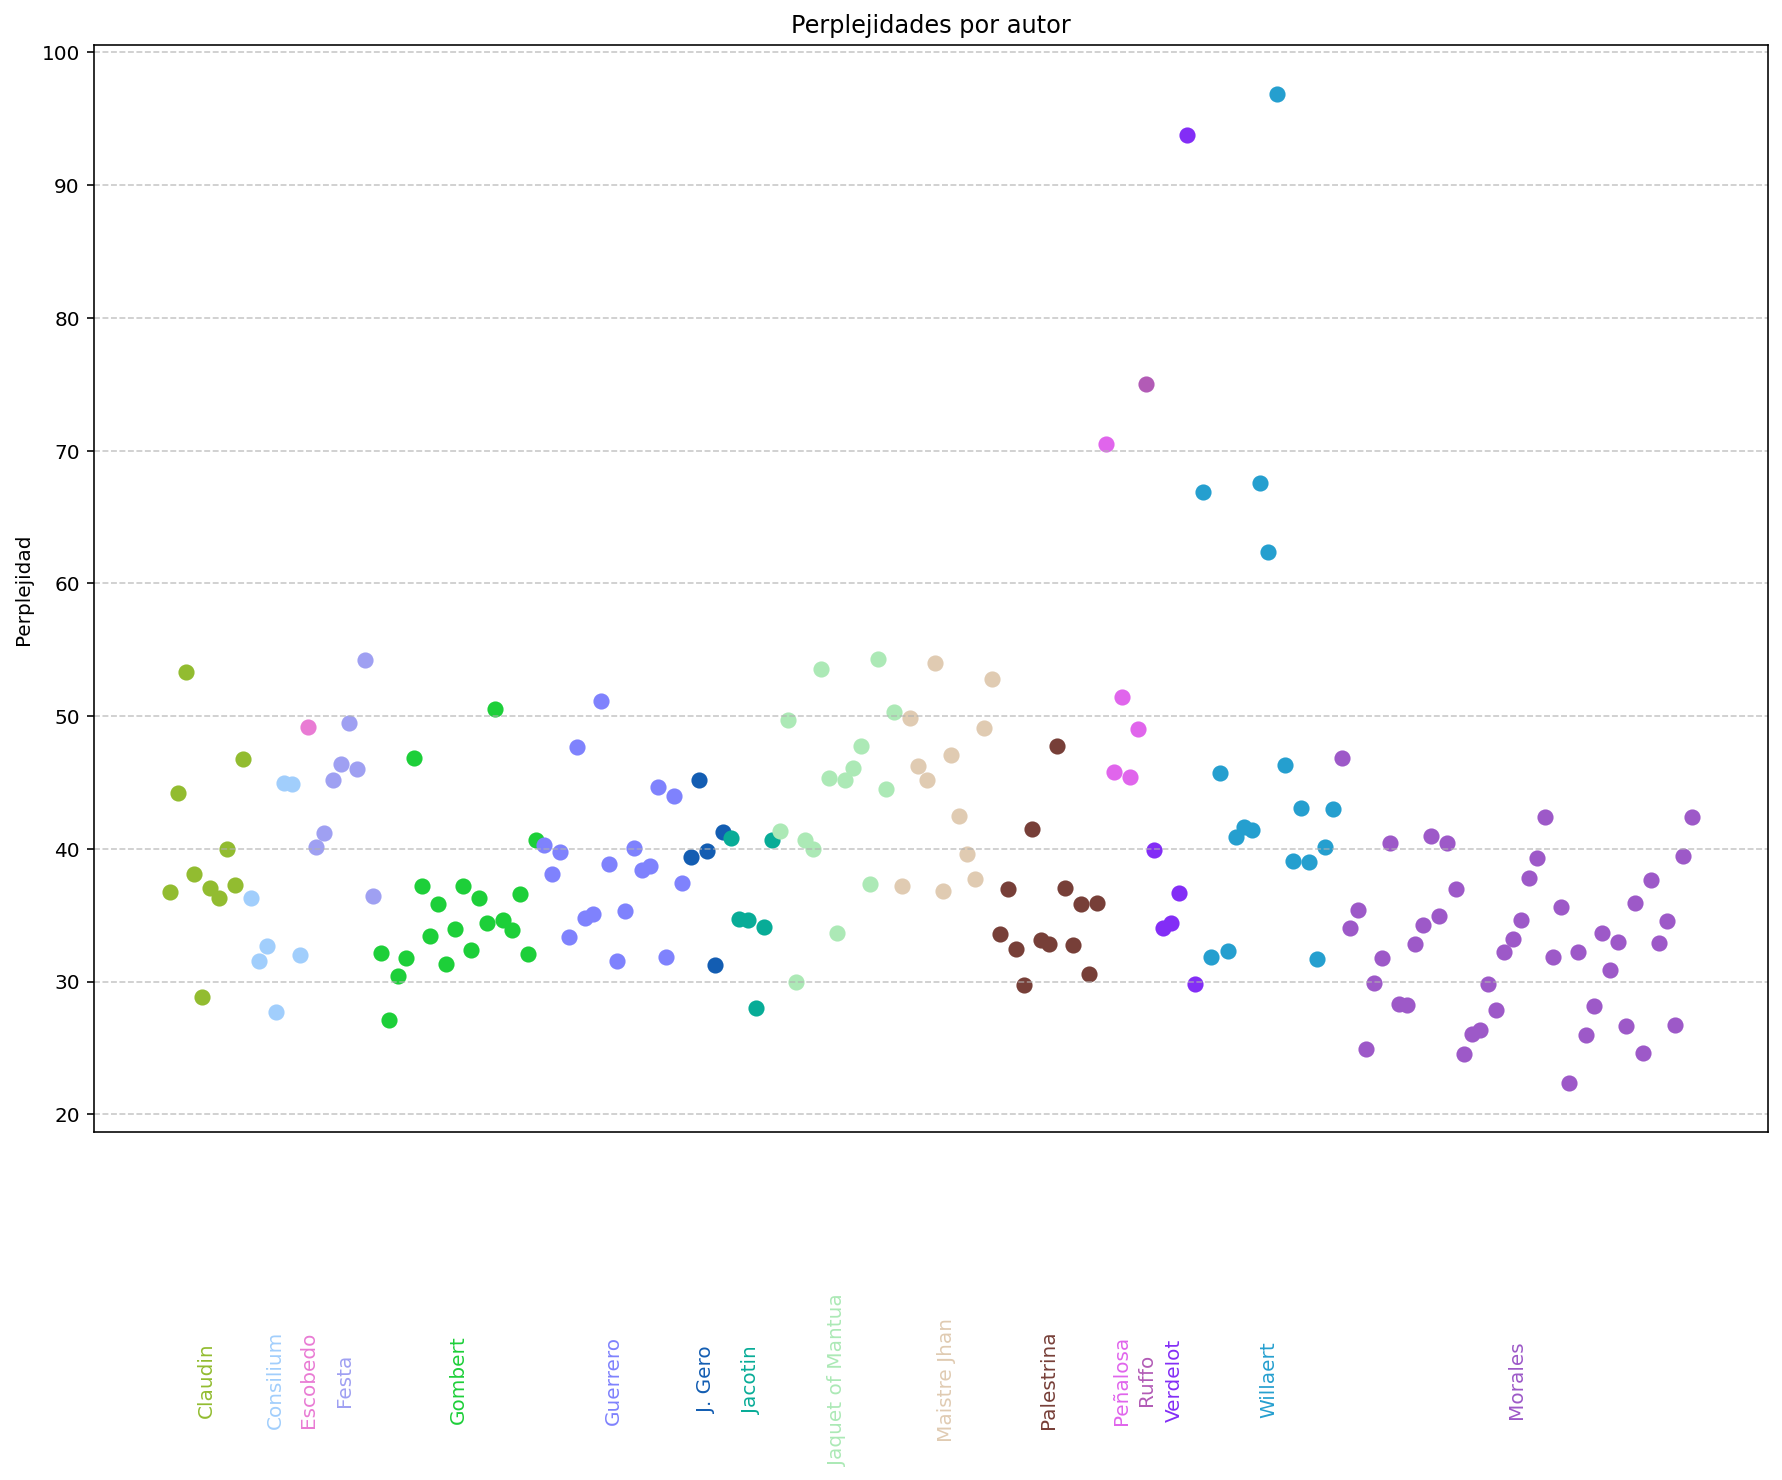

In [27]:
grafico2 = plt_individuals_colored(otros_fnames_and_others[2], n_test, pp)
plt.show()

#### Tercera visualización

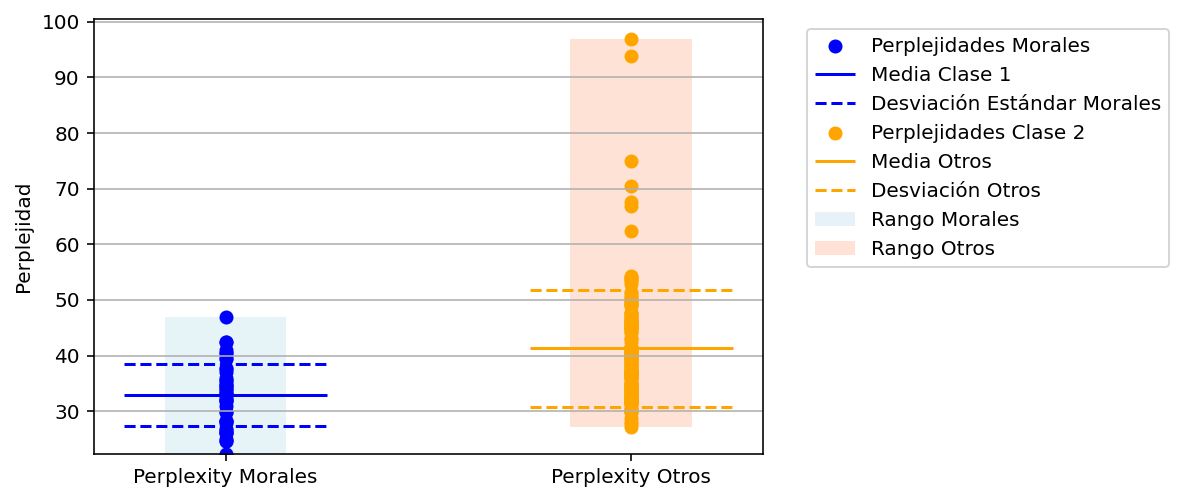

In [28]:
grafico3 = plt_by_classes(max_morales, max_otros, min_morales, min_otros, desviacion_morales, desviacion_otros, media_morales, media_otros, pp_morales, pp_otros)
grafico3.savefig('bassus_morales_model_folded_everycategory.svg')
## esta función no está muy bien desarrollada (temporal).

#### Cuarta visualización

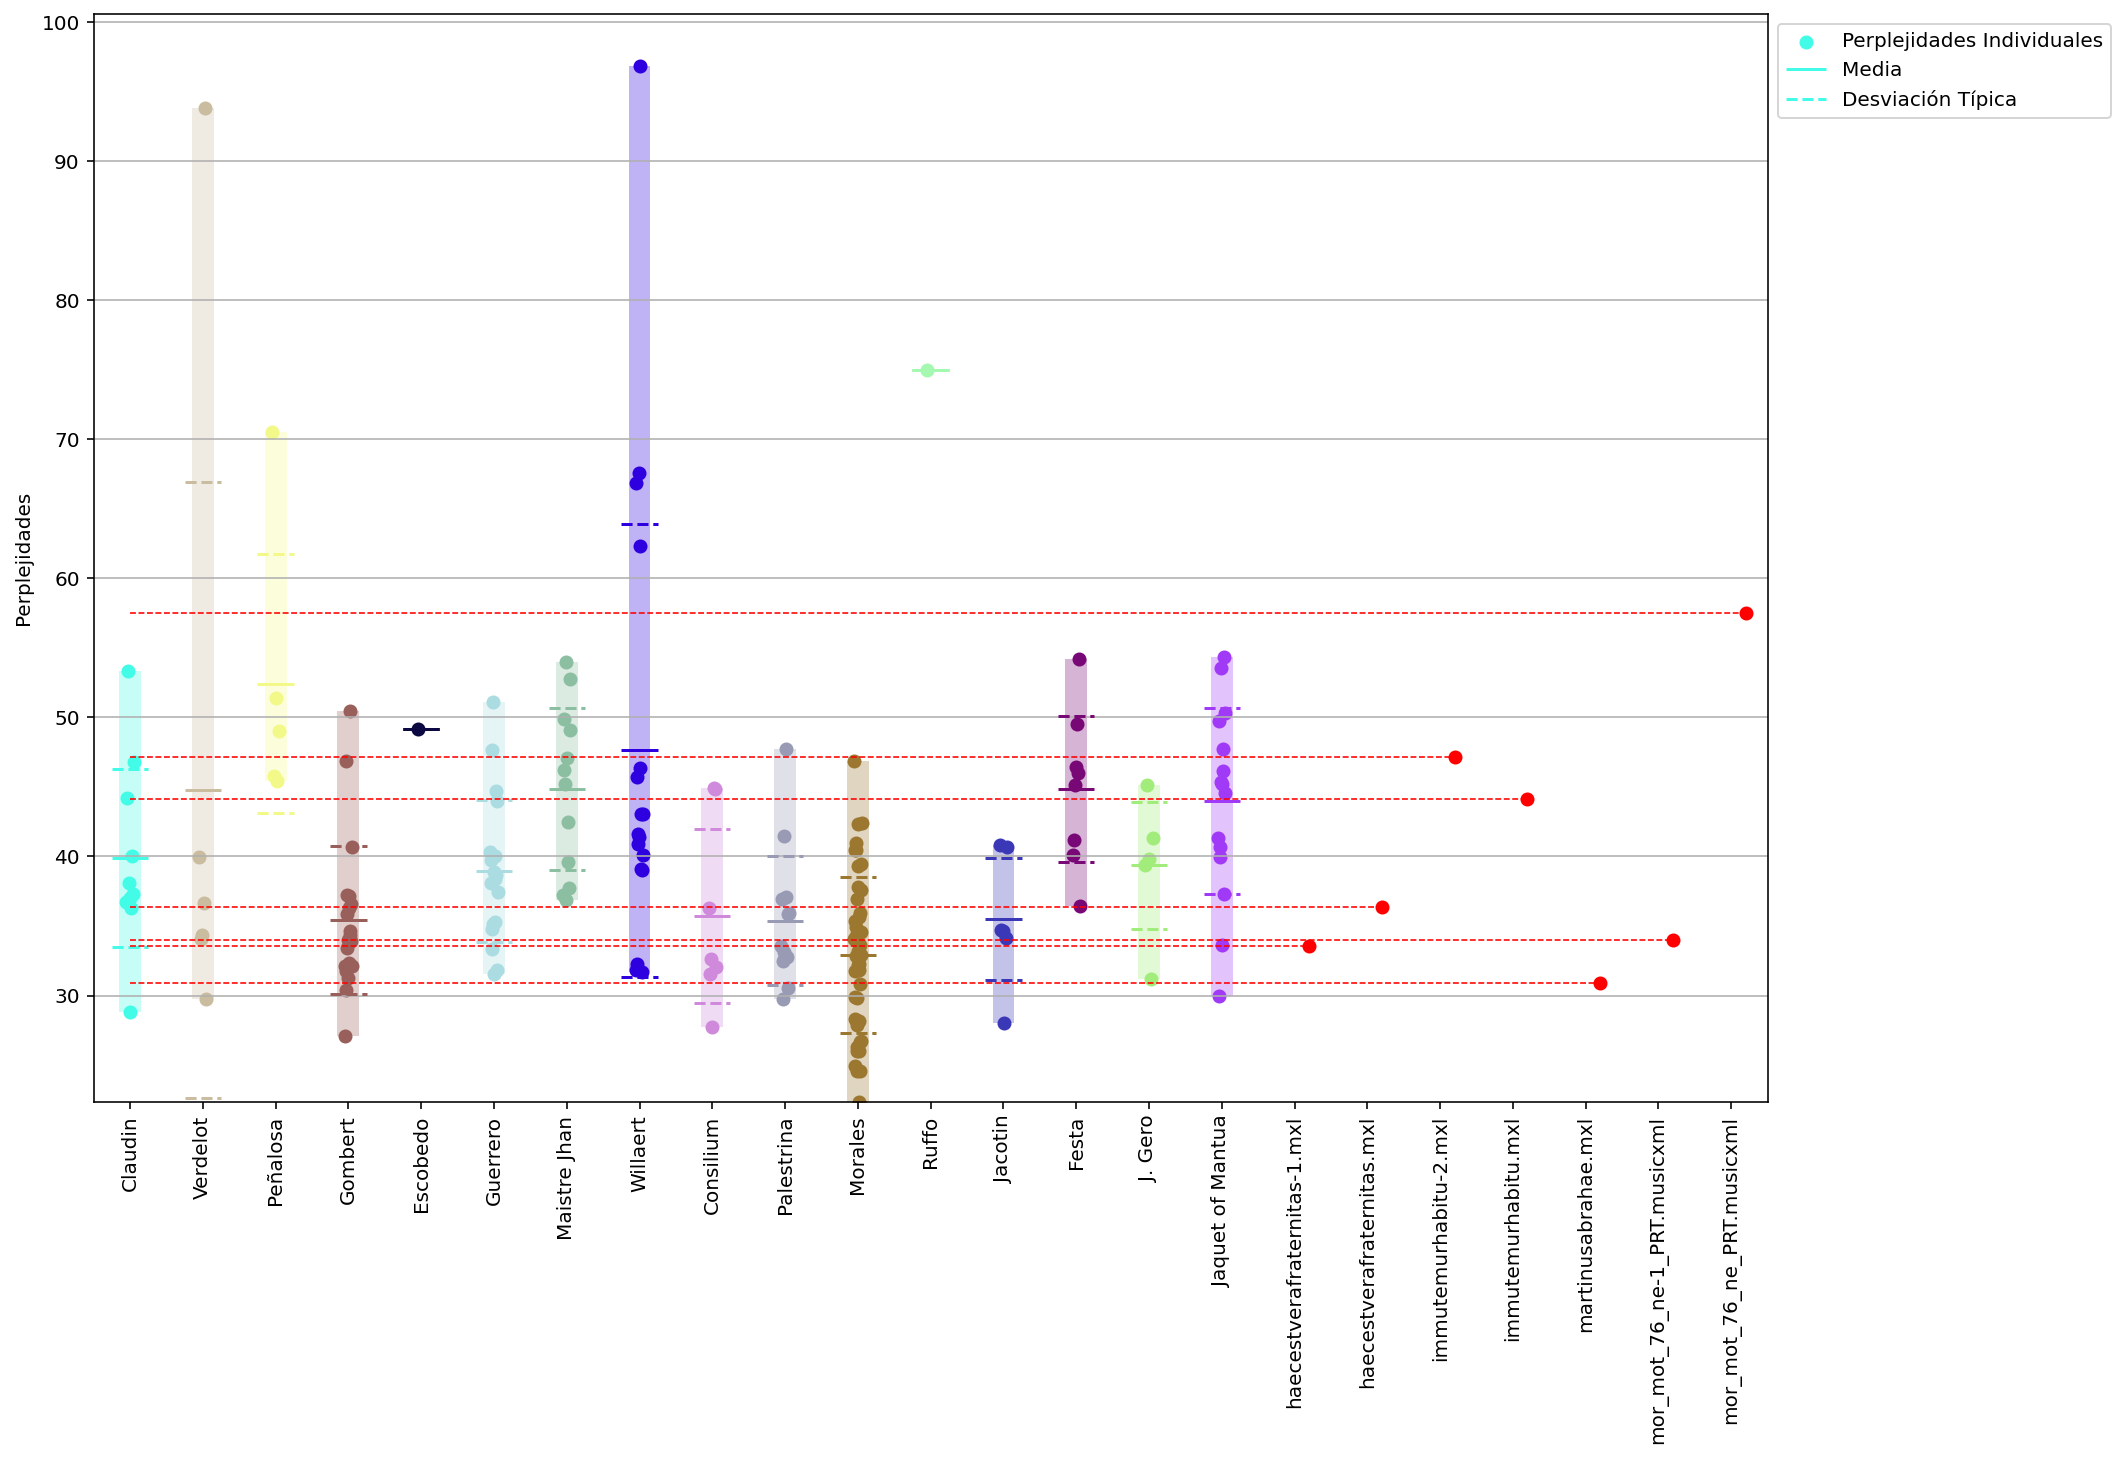

In [30]:
grafico4 = plt_folded(otros_fnames_and_others[2], n_test, pp, test_files_4, pp_test)
grafico4.savefig('everything_morales_model_everycategory.svg')

#### Revisión de archivos de perplejidades extremas

In [ ]:
## cata de archivos con perplejidades 
#muy altas y muy bajas en ambas categorías

def perplexity_dic(pp, fnames):
    result_dic = dict.fromkeys(pp)
    for key, value in zip(list(result_dic.keys()), fnames):
        result_dic[key] = value
    return result_dic

def extreme_pp(dev, dct, mean):
    max_cutoff = mean + dev
    min_cutoff = mean - dev
    rst = dict()
    for i,e in dct.items():
        if i > max_cutoff or i < min_cutoff:
            rst[i] = e
    return rst

## estas variables se requieren en lo sucesivo
pp_dct_morales = perplexity_dic(pp_morales, z_test)
desviacion_morales = np.std(list(pp_dct_morales.keys()))
media_morales = np.mean(pp_morales)
pp_dct_otros = perplexity_dic(pp_otros, otros_files)
desviacion_otros = np.std(list(pp_dct_otros.keys()))
media_otros = np.mean(pp_otros)
###############################

## Archivos con valores extremos para Morales y otros

ext_morales = extreme_pp(desviacion_morales, pp_dct_morales, media_morales)
ext_otros = extreme_pp(desviacion_otros, pp_dct_otros, media_otros)
ext_morales = pd.DataFrame({'Files': ext_morales.values(), 'Perp.': ext_morales.keys()})
ext_otros = pd.DataFrame({'Files': ext_otros.values(), 'Perp.': ext_otros.keys()})


In [ ]:
ext_morales.sort_values(by=['Perp.'], ascending=False)

In [ ]:
ext_otros.sort_values(by=['Perp.'])

#### Ver dentro de los datos de algunos archivos la distribución de frecuencias y el vocabulario. DE UNO EN UNO

In [ ]:
## peor predición de Morales

morales_bad_prediction = corpora_parser(n, [['mor_mot_9_ne-2_PRT.musicxml'],'All',['Morales'],''], ['']*4, base40=True, stack=stack, mode=mode, voice_selec=voice_selec)
morales_words_bad_prediction = morales_bad_prediction[1]
morales_ngrams_bad_prediction = morales_bad_prediction[0]
iors_hist_bad_prediction = Counter(morales_bad_prediction[2])

In [ ]:
##Mejor predicción de Morales

morales_good_prediction = corpora_parser(n, [['mor_mis_18_5_ne.musicxml'],'All',['Morales'],''], ['']*4, base40=True, stack=stack, mode=mode, voice_selec=voice_selec)
morales_words_good_prediction = morales_good_prediction[1]
morales_ngrams_good_prediction = morales_good_prediction[0]
iors_hist_good_prediction = Counter(morales_good_prediction[2])

In [ ]:
## distrinbuciones de frecuencias
# Morales bien

mor_fdist_good = nltk.FreqDist(morales_words_good_prediction[0])

# Morales mal

mor_fdist_bad = nltk.FreqDist(morales_words_bad_prediction[0])

In [ ]:
mor_fdist_bad

In [ ]:
## Comparación: unión, intersección, similaridad Jaccard

intersec = set(mor_fdist_good).intersection(set(mor_fdist_bad))
union = set(mor_fdist_good).union(set(mor_fdist_bad))

print(union)
print(intersec)
jaccard_similarity = len(intersec) / len(union)
print(f"Similitud de Jaccard: {jaccard_similarity}")

In [ ]:
# Otra opción: comparar frecuencias directamente en palabras comunes
common_words = set(mor_fdist_good).intersection(set(mor_fdist_bad))
for word in common_words:
    freq1 = mor_fdist_good[word]
    freq2 = mor_fdist_bad[word]
    print(f"Palabra: {word}, Frecuencia en conteo 1: {freq1}, Frecuencia en conteo 2: {freq2}")

#### Trabajo próximo

Explorar la reversión de las features, para ver exactamente qué características son las mostradas arriba.